# Voice of Customer Copilot: Dataset Inspection & Exploratory Data Analysis

**Notebook**: `notebooks/01_dataset_inspection.ipynb`  
**Source Dataset**: `data/raw/public_reviews.csv`  
**Objective**: Conduct an exploratory analysis of the raw public customer reviews dataset to understand structure, data quality, distributions, and schema mapping for the Voice of Customer (VoC) pipeline.

> **Note**: This is an exploratory analysis notebook only. The raw source dataset is preserved without modification.

## 1. Import Libraries
Import standard libraries for data handling (`pandas`, `numpy`) and visualization (`matplotlib`).

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 1000)

# Matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Dataset
Load `data/raw/public_reviews.csv` and verify successful loading.

In [2]:
# Resolve data path relative to current execution context
possible_paths = [
    Path('../data/raw/public_reviews.csv'),
    Path('data/raw/public_reviews.csv'),
    Path(os.getcwd()) / 'data' / 'raw' / 'public_reviews.csv'
]

data_path = None
for p in possible_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError('Could not find data/raw/public_reviews.csv')

df = pd.read_csv(data_path)
print(f"✓ Confirmation: Successfully loaded dataset from '{data_path}'")
print(f"✓ Total rows loaded: {len(df):,}")

✓ Confirmation: Successfully loaded dataset from 'data\raw\public_reviews.csv'
✓ Total rows loaded: 205,052


## 3. Dataset Overview
Display number of rows, number of columns, column names, and data types.

In [3]:
num_rows, num_cols = df.shape
print(f"Number of rows:    {num_rows:,}")
print(f"Number of columns: {num_cols}")
print("\nDataset Overview Summary Table:")
overview_table = pd.DataFrame({
    'Column Name': df.columns,
    'Inferred Data Type': [str(dt) for dt in df.dtypes],
    'Non-Null Count': [df[c].notnull().sum() for c in df.columns],
    'Null Count': [df[c].isnull().sum() for c in df.columns]
})
display(overview_table)

Number of rows:    205,052
Number of columns: 6

Dataset Overview Summary Table:


,Column Name,Inferred Data Type,Non-Null Count,Null Count
0,product_name,str,205052,0
1,product_price,str,205052,0
2,Rate,str,205052,0
3,Review,str,180388,24664
4,Summary,str,205041,11
5,Sentiment,str,205052,0


## 4. First 10 Records
Display the first 10 rows of the customer reviews dataset.

In [4]:
df.head(10)

,product_name,product_price,Rate,Review,Summary,Sentiment
0,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,5,super!,great cooler excellent air flow and for this price its so amazing and unbelievablejust love it,positive
1,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,3,fair,the quality is good but the power of air is decent,positive
3,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,1,useless product,very bad product its a only a fan,negative
4,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,3,fair,ok ok product,neutral
5,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,5,awesome,the cooler is really fantastic and provides good air flow highly recommended,positive
6,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,5,highly recommended,very good product,positive
7,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,3,nice,very nice,positive
8,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,1,unsatisfactory,very bad cooler,negative
9,"Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",3999,4,worth the money,very good,positive


## 5. Random Sample
Display 10 random records using a fixed `random_state=42` to inspect arbitrary records across products.

In [5]:
df.sample(10, random_state=42)

,product_name,product_price,Rate,Review,Summary,Sentiment
193551,BAJAJ 17 L Solo Microwave Oven1701MT White,4498,1,worst experience ever!,not working properly,neutral
149083,ScotchBrite Sponge WipeLarge Pack of 3,189,5,just wow!,very good,positive
194975,limraz furniture Engineered Wood Computer DeskStraight Finish Color brown Preassembled,1298,5,classy product,it is perfect if you want to work on the computer write something or eat the size is super perfect well calculated and well researched the table occupies very less space and can be shifted anywher...,positive
29981,"Lakm?? Eyeconic Kajal Twin Pack??????(Deep Black, 0.7 g)",218,5,simply awesome,thanks flipkart,positive
137259,KENT Aura Portable Room Air PurifierPink,6999,5,simply awesome,thanks product looks good not sure if any installation service will be provided utomatically or i have to register for this anywhere,positive
19774,WD Elements 2 TB Wired External Hard Disk Drive (HDD)??????????(Black),5499,5,just wow!,super product early delivery worth for 15 tb light weight easy to handle fast data transfer rate recommending 15 tb for this price,positive
41823,"Top - Pyjama Set Thermal For Boys & Girls??????(Multicolor, Pack of 3)",365,5,NaN,good quality at very reasonable price,positive
199575,"cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÃÂ ÃÂ (White, Microwave Safe)",1299,4,value-for-money,great product thank you,positive
126858,AGARO Regal Hand-held Vacuum CleanerÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ (Black),1599,4,really nice,value for money,positive
134339,Pureit Advanced Plus RO? 7 L RO MF Water PurifierÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ (Black),7799,4,good choice,best in market,positive


## 6. Missing Values
Inspect missing values count and missing percentage for every column.

In [6]:
missing_counts = df.isnull().sum()
missing_pcts = (missing_counts / len(df) * 100).round(3)

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_counts.values,
    'Missing Percentage (%)': missing_pcts.values
}).sort_values(by='Missing Count', ascending=False).reset_index(drop=True)

display(missing_df)

total_nulls = df.isnull().sum().sum()
total_cells = df.size
print(f"Total missing data points: {total_nulls:,} / {total_cells:,} total cells ({(total_nulls/total_cells)*100:.2f}%)")

,Column,Missing Count,Missing Percentage (%)
0,Review,24664,12.028
1,Summary,11,0.005
2,product_price,0,0.000
3,product_name,0,0.000
4,Rate,0,0.000
5,Sentiment,0,0.000


Total missing data points: 24,675 / 1,230,312 total cells (2.01%)


## 7. Duplicate Analysis
Calculate the number and percentage of completely duplicated rows.

In [7]:
dup_count = df.duplicated().sum()
dup_pct = (dup_count / len(df)) * 100

print(f"Number of completely duplicated rows: {dup_count:,}")
print(f"Percentage of duplicated rows:         {dup_pct:.2f}%")

if dup_count > 0:
    print("\nSample duplicated rows (showing first 6 pairs):")
    display(df[df.duplicated(keep=False)].head(6))

Number of completely duplicated rows: 34,375
Percentage of duplicated rows:         16.76%

Sample duplicated rows (showing first 6 pairs):


,product_name,product_price,Rate,Review,Summary,Sentiment
92,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,5,highly recommended,awesome,positive
93,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,5,fabulous!,good product,positive
95,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,5,great product,very good,positive
100,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,5,mind-blowing purchase,awesome product,positive
113,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,4,good quality product,good,positive
125,"MAHARAJA WHITELINE 65 L Desert Air Cooler??????(White, Grey, Rambo Grey / AC-303)",7999,5,perfect product!,good product,positive


## 8. Unique Values
Examine the number and ratio of unique values for each column.

In [8]:
unique_table = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[c].nunique(dropna=True) for c in df.columns],
    'Unique Ratio (%)': [(df[c].nunique(dropna=True) / len(df) * 100) for c in df.columns]
})
display(unique_table)

,Column,Unique Values,Unique Ratio (%)
0,product_name,958,0.467199
1,product_price,525,0.256033
2,Rate,8,0.003901
3,Review,1324,0.645690
4,Summary,92923,45.316798
5,Sentiment,3,0.001463


## 9. Numerical Analysis
Examine summary statistics for numerical attributes (ratings and prices).

In [9]:
# Safe numerical conversion of Rate
rate_numeric = pd.to_numeric(df['Rate'], errors='coerce')
print("Descriptive statistics for 'Rate' (parsed as numeric):")
display(rate_numeric.describe(percentiles=[0.25, 0.5, 0.75]).to_frame(name='Rate Statistics'))

# Safe numerical conversion of product_price (stripping currency symbols)
price_cleaned = df['product_price'].astype(str).str.replace('₹', '', regex=False).str.replace(',', '', regex=False)
price_numeric = pd.to_numeric(price_cleaned, errors='coerce')
print("\nDescriptive statistics for 'product_price' (parsed as numeric INR):")
display(price_numeric.describe(percentiles=[0.25, 0.5, 0.75]).to_frame(name='Price Statistics (₹)'))

Descriptive statistics for 'Rate' (parsed as numeric):


,Rate Statistics
count,205049.000000
mean,4.123307
std,1.306323
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000



Descriptive statistics for 'product_price' (parsed as numeric INR):


,Price Statistics (₹)
count,205049.000000
mean,4135.165712
std,9881.936686
min,59.000000
25%,319.000000
50%,675.000000
75%,2999.000000
max,86990.000000


## 10. Rating Analysis
Evaluate the distribution of customer ratings in the `Rate` column, including frequency table, percentage distribution, and bar chart.

,Rating Value,Count,Percentage (%)
0,5,118765,57.92
1,4,41894,20.43
2,1,21300,10.39
3,3,16599,8.10
4,2,6491,3.17
5,"Pigeon Favourite Electric Kettle??????(1.5 L, Silver, Black)",1,0.00
6,Bajaj DX 2 L/W Dry Iron,1,0.00
7,Nova Plus Amaze NI 10 1100 W Dry Iron?ÃÂ¿?ÃÂ¿(Grey & Turquoise),1,0.00


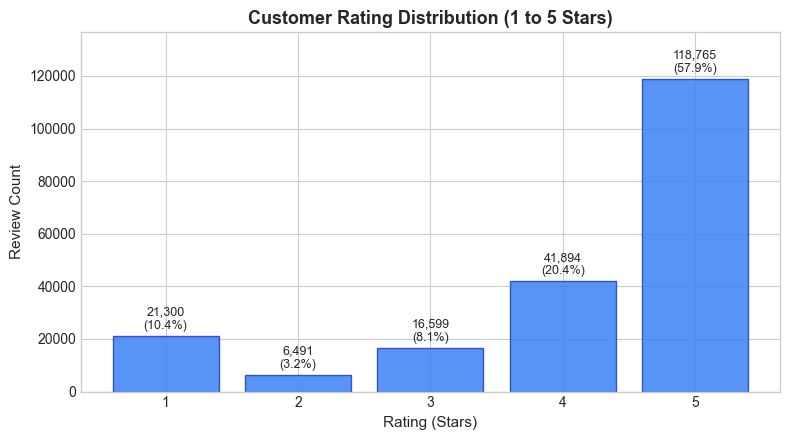

In [10]:
rate_counts = df['Rate'].value_counts(dropna=False)
rate_pcts = (df['Rate'].value_counts(normalize=True, dropna=False) * 100).round(2)

rate_summary = pd.DataFrame({
    'Rating Value': rate_counts.index.astype(str),
    'Count': rate_counts.values,
    'Percentage (%)': rate_pcts.values
})
display(rate_summary)

# Standard 1-5 star ratings visualization
valid_ratings = df['Rate'].loc[df['Rate'].isin(['1', '2', '3', '4', '5'])].value_counts().sort_index()

plt.figure(figsize=(8, 4.5))
bars = plt.bar(valid_ratings.index, valid_ratings.values, color='#3b82f6', edgecolor='#1e40af', alpha=0.85)
plt.title('Customer Rating Distribution (1 to 5 Stars)', fontsize=13, fontweight='bold')
plt.xlabel('Rating (Stars)', fontsize=11)
plt.ylabel('Review Count', fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1500, f'{yval:,}\n({(yval/len(df)*100):.1f}%)', ha='center', va='bottom', fontsize=9)
plt.ylim(0, max(valid_ratings.values) * 1.15)
plt.tight_layout()
plt.show()

## 11. Sentiment Analysis
Evaluate the distribution of pre-labeled sentiment classes in the `Sentiment` column.

,Sentiment,Count,Percentage (%)
0,positive,166581,81.24
1,negative,28232,13.77
2,neutral,10239,4.99


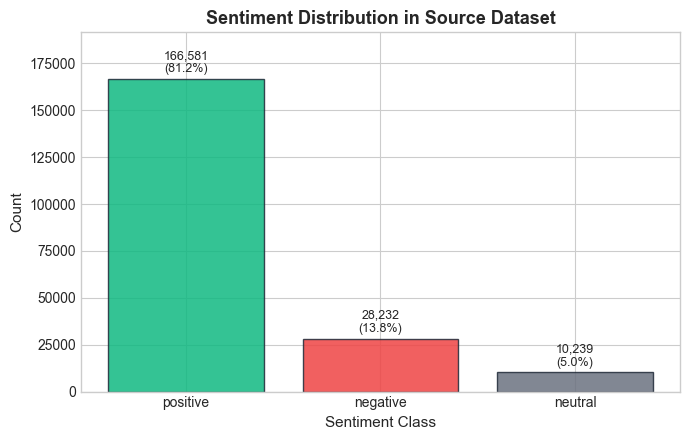

In [11]:
sentiment_counts = df['Sentiment'].value_counts(dropna=False)
sentiment_pcts = (df['Sentiment'].value_counts(normalize=True, dropna=False) * 100).round(2)

sentiment_summary = pd.DataFrame({
    'Sentiment': sentiment_counts.index,
    'Count': sentiment_counts.values,
    'Percentage (%)': sentiment_pcts.values
})
display(sentiment_summary)

# Bar chart with semantic colors
colors = {'positive': '#10b981', 'negative': '#ef4444', 'neutral': '#6b7280'}
bar_colors = [colors.get(s, '#3b82f6') for s in sentiment_counts.index]

plt.figure(figsize=(7, 4.5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, edgecolor='#1f2937', alpha=0.85)
plt.title('Sentiment Distribution in Source Dataset', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment Class', fontsize=11)
plt.ylabel('Count', fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2000, f'{yval:,}\n({(yval/len(df)*100):.1f}%)', ha='center', va='bottom', fontsize=9)
plt.ylim(0, max(sentiment_counts.values) * 1.15)
plt.tight_layout()
plt.show()

## 12. Product Analysis
Identify product and category columns, and show the top 20 most reviewed products.

Identified Product Column: 'product_name'


Total Unique Products:    958


,Product Name,Review Count,Percentage (%)
0,"cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÃÂ ÃÂ (White, Microwave Safe)",6005,2.93
1,"Lakm?? Eyeconic Kajal Twin Pack??????????(Deep Black, 0.7 g)",5000,2.44
2,Mi 5A 80 cm (32 inch) HD Ready LED Smart Android TV with Dolby Audio (2022 Model),2205,1.08
3,cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set 18 Pieces Dinner SetWhite Microwave Safe,2095,1.02
4,Home Sizzler 153 cm 502 ft Polyester Room Darkening Window Curtain Pack Of 2Floral Brown,2012,0.98
5,"Mi 3i 10000 mAh Power Bank (Fast Charging, 18W)ÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ (Blue, Lithium Polymer)",2006,0.98
6,Singer FM 1409 Electric Sewing MachineÐÒ?ÐÓ®ÐÂ ÐÒ?ÐÓ®ÐÂ ( Built-in Stitches 9),2003,0.98
7,Men Cargos,2000,0.98
8,"Lakm?? Eyeconic Kajal Twin Pack??????(Deep Black, 0.7 g)",1999,0.97
9,"HAIR & CARE Triple Blend Damage Repair Non-Sticky Hair Oil with Aloe Vera, For Dry, Rough, & Frizzy Hair, Hair OilÐÓ®ÐÂ ÐÓ®ÐÂ (400 ml)",1999,0.97


C:\Users\Ishit\AppData\Local\Temp\ipykernel_21928\2466379672.py:22: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ishit\AppData\Local\Temp\ipykernel_21928\2466379672.py:22: UserWarning: Glyph 146 (\x92) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ishit\AppData\Local\Temp\ipykernel_21928\2466379672.py:22: UserWarning: Glyph 157 (\x9d) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\Ishit\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Ishit\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Ishit\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 157 (\x9d) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


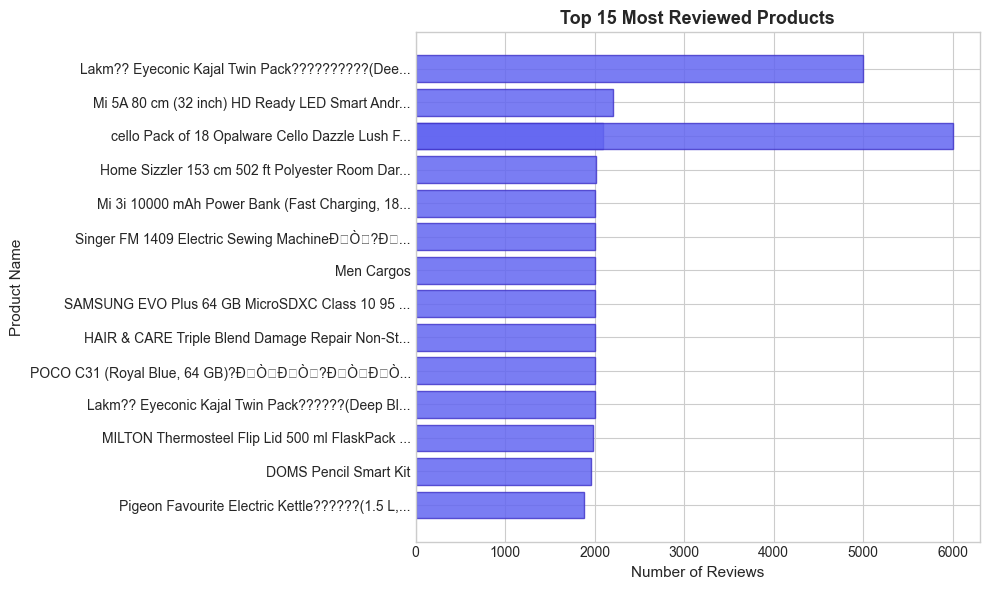

In [12]:
product_col = 'product_name'
print(f"Identified Product Column: '{product_col}'")
print(f"Total Unique Products:    {df[product_col].nunique():,}")

top_20 = df[product_col].value_counts().head(20)
top_20_df = pd.DataFrame({
    'Product Name': top_20.index,
    'Review Count': top_20.values,
    'Percentage (%)': (top_20.values / len(df) * 100).round(2)
})
display(top_20_df)

# Horizontal bar chart for top 15 products
top_15 = top_20.head(15).sort_values(ascending=True)
short_labels = [name[:45] + '...' if len(name) > 45 else name for name in top_15.index]

plt.figure(figsize=(10, 6))
plt.barh(short_labels, top_15.values, color='#6366f1', edgecolor='#4338ca', alpha=0.85)
plt.title('Top 15 Most Reviewed Products', fontsize=13, fontweight='bold')
plt.xlabel('Number of Reviews', fontsize=11)
plt.ylabel('Product Name', fontsize=11)
plt.tight_layout()
plt.show()

## 13. Review Text Analysis
Identify the main review text column vs review title/tagline, compute character length metrics, and plot the length distribution.

Review text columns identified in dataset:
  - 'Summary': Main detailed feedback body
  - 'Review':  Short review headline / title


,Metric,Summary (Main Feedback Body),Review (Headline / Title)
0,Minimum,1.00,2.00
1,25th Percentile (Q1),9.00,9.00
2,Median (50%),17.00,12.00
3,Mean,42.23,12.62
4,75th Percentile (Q3),41.00,16.00
5,Maximum,497.00,140.00


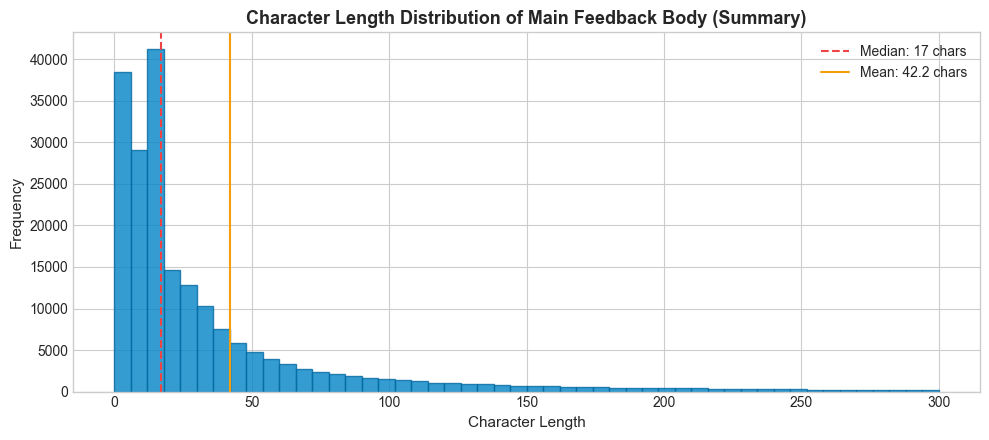

In [13]:
# Clarify the two text columns:
# 1. 'Summary' -> Main detailed review body (mean 42 chars, max 497 chars)
# 2. 'Review'  -> Short review headline/title (mean 12.6 chars, max 140 chars)
print("Review text columns identified in dataset:")
print("  - 'Summary': Main detailed feedback body")
print("  - 'Review':  Short review headline / title")

summary_lengths = df['Summary'].dropna().astype(str).str.len()
review_lengths = df['Review'].dropna().astype(str).str.len()

stats_df = pd.DataFrame({
    'Metric': ['Minimum', '25th Percentile (Q1)', 'Median (50%)', 'Mean', '75th Percentile (Q3)', 'Maximum'],
    'Summary (Main Feedback Body)': [
        summary_lengths.min(),
        summary_lengths.quantile(0.25),
        summary_lengths.median(),
        round(summary_lengths.mean(), 2),
        summary_lengths.quantile(0.75),
        summary_lengths.max()
    ],
    'Review (Headline / Title)': [
        review_lengths.min(),
        review_lengths.quantile(0.25),
        review_lengths.median(),
        round(review_lengths.mean(), 2),
        review_lengths.quantile(0.75),
        review_lengths.max()
    ]
})
display(stats_df)

# Histogram of main review text length
plt.figure(figsize=(10, 4.5))
plt.hist(summary_lengths, bins=50, range=(0, 300), color='#0284c7', edgecolor='#0369a1', alpha=0.8)
plt.axvline(summary_lengths.median(), color='#ef4444', linestyle='--', linewidth=1.5, label=f'Median: {summary_lengths.median():.0f} chars')
plt.axvline(summary_lengths.mean(), color='#f59e0b', linestyle='-', linewidth=1.5, label=f'Mean: {summary_lengths.mean():.1f} chars')
plt.title('Character Length Distribution of Main Feedback Body (Summary)', fontsize=13, fontweight='bold')
plt.xlabel('Character Length', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Review Examples
Display 10 positive, 10 negative, and 10 neutral reviews.

In [14]:
def display_examples(sentiment_label: str, n: int = 10):
    samples = df[df['Sentiment'] == sentiment_label].sample(n, random_state=42)[['product_name', 'Rate', 'Review', 'Summary']]
    print(f"\n{'='*85}")
    print(f"10 Sample '{sentiment_label.upper()}' Reviews")
    print(f"{'='*85}")
    for idx, (_, r) in enumerate(samples.iterrows(), 1):
        print(f"[{idx:02d}] Product:  {r['product_name'][:65]}...")
        print(f"     Rating:   {r['Rate']} Stars")
        print(f"     Headline: {r['Review']}")
        print(f"     Body:     {r['Summary']}\n")

display_examples('positive', 10)
display_examples('negative', 10)
display_examples('neutral', 10)


10 Sample 'POSITIVE' Reviews
[01] Product:  DivineCrafts Om Swastik 2 Pocket penstand Wood Key Holder8 Hooks ...
     Rating:   5 Stars
     Headline: must buy!
     Body:     excellent

[02] Product:  POCO C31 (Royal Blue, 64 GB)?ÐÒÐÒ?ÐÒÐÒ(4 GB RAM)...
     Rating:   5 Stars
     Headline: awesome
     Body:     good phone

[03] Product:  HAIR & CARE Triple Blend Damage Repair Non-Sticky Hair Oil with A...
     Rating:   3 Stars
     Headline: decent product
     Body:     supar

[04] Product:  Mivi Fort S16 Soundbar with 2 full range drivers, Made in India 1...
     Rating:   5 Stars
     Headline: excellent
     Body:     thnku for this wonderful product

[05] Product:  Women Regular Fit Cream Viscose Rayon Trousers...
     Rating:   5 Stars
     Headline: nan
     Body:     very nice

[06] Product:  HAIR & CARE Triple Blend Damage Repair Non-Sticky Hair Oil with A...
     Rating:   5 Stars
     Headline: brilliant
     Body:     i liked this hair oil it is light on scalp i


10 Sample 'NEUTRAL' Reviews
[01] Product:  NIVIA Storm Football - Size: 5ÐÓ®ÐÂ ÐÓ®ÐÂ (Pack of 1, Multico...
     Rating:   5 Stars
     Headline: fabulous!
     Body:     must buy

[02] Product:  Butterfly Rhino Plus Wet Grinder?ÐÒÐÒ?ÐÒÐÒ(Grey)...
     Rating:   3 Stars
     Headline: decent product
     Body:     average

[03] Product:  Prestige Plus Atlas 750 W Juicer Mixer Grinder (4 Jars, Blue, Whi...
     Rating:   5 Stars
     Headline: excellent
     Body:     ok

[04] Product:  Men LPMXT-800 Grey Clogs Sandal...
     Rating:   5 Stars
     Headline: nan
     Body:     quality is very good buy one size large

[05] Product:  cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinne...
     Rating:   3 Stars
     Headline: does the job
     Body:     plates are 10 incheslittle small quality oknot bad

[06] Product:  HARIOM ALL IN ONE Solid Wood Study TableFinish Color  MOTU PATLU ...
     Rating:   3 Stars
     Headline: decent product
     Body:     okay

[07

## 15. Date Analysis
Inspect all columns for date or timestamp information.

In [15]:
print("Checking all columns for date-like or temporal data:\n")
for col in df.columns:
    samples = df[col].dropna().head(10).astype(str).tolist()
    print(f"Column '{col}': Sample values -> {samples[:2]}")

print("\n" + "="*60)
print("DATE ANALYSIS RESULT:")
print("="*60)
print("Explicit Finding: Date information is completely unavailable in public_reviews.csv.")
print("None of the 6 columns ('product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment') contains timestamps or dates.")
print("="*60)

Checking all columns for date-like or temporal data:

Column 'product_name': Sample values -> ['Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)', 'Candes 12 L Room/Personal Air Cooler??????(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)']
Column 'product_price': Sample values -> ['3999', '3999']
Column 'Rate': Sample values -> ['5', '5']
Column 'Review': Sample values -> ['super!', 'awesome']
Column 'Summary': Sample values -> ['great cooler excellent air flow and for this price its so amazing and unbelievablejust love it', 'best budget 2 fit cooler nice cooling']
Column 'Sentiment': Sample values -> ['positive', 'positive']

DATE ANALYSIS RESULT:
Explicit Finding: Date information is completely unavailable in public_reviews.csv.
None of the 6 columns ('product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment') contains timestamps or dates.


## 16. VoC Schema Mapping
Map the available source dataset columns to the target Voice of Customer (VoC) schema fields.

In [16]:
schema_mapping_data = [
    {
        'Target Field': 'feedback_id',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Generate unique ID per review (e.g. `fb_000001` or UUID/row-hash)',
        'Notes': 'Source dataset does not provide review IDs.'
    },
    {
        'Target Field': 'source_type',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Assign static metadata constant (e.g. `ecommerce_review`)',
        'Notes': 'Not available from source dataset.'
    },
    {
        'Target Field': 'source_name',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Assign static source label (e.g. `Public Product Reviews`)',
        'Notes': 'Not available from source dataset.'
    },
    {
        'Target Field': 'feedback_text',
        'Available From Dataset?': 'Yes',
        'Original Column': 'Summary (body) & Review (headline)',
        'Transformation Required': 'Use `Summary` as main text or combine `Review` + `Summary`',
        'Notes': '`Summary` holds the core customer feedback body; `Review` holds the short headline.'
    },
    {
        'Target Field': 'created_at',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Generate synthetic timestamp distribution (if trend analysis is required)',
        'Notes': 'Not available from source dataset.'
    },
    {
        'Target Field': 'customer_segment',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Derive via price tiers or synthetic cohort assignment',
        'Notes': 'Not available from source dataset.'
    },
    {
        'Target Field': 'product_area',
        'Available From Dataset?': 'Partially',
        'Original Column': 'product_name',
        'Transformation Required': 'Extract appliance/product category keywords from `product_name`',
        'Notes': 'Product titles contain category keywords (e.g. Cooler, Iron, Kettle, Juicer).'
    },
    {
        'Target Field': 'sentiment',
        'Available From Dataset?': 'Yes',
        'Original Column': 'Sentiment',
        'Transformation Required': 'Normalize casing (`positive`, `negative`, `neutral`)',
        'Notes': 'Pre-labeled sentiment is available across all rows.'
    },
    {
        'Target Field': 'severity',
        'Available From Dataset?': 'Partially (derived)',
        'Original Column': 'Rate & Sentiment',
        'Transformation Required': 'Calculate from rating (e.g. 1-star negative = High severity)',
        'Notes': 'Explicit severity score is not in dataset; must be computed or derived.'
    },
    {
        'Target Field': 'language',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Default to `en` or run lightweight language detector',
        'Notes': 'Not available from source dataset.'
    },
    {
        'Target Field': 'data_type',
        'Available From Dataset?': 'No',
        'Original Column': 'Not available from source dataset.',
        'Transformation Required': 'Assign static label (e.g. `customer_review`)',
        'Notes': 'Not available from source dataset.'
    }
]

schema_table = pd.DataFrame(schema_mapping_data)
display(schema_table)

,Target Field,Available From Dataset?,Original Column,Transformation Required,Notes
0,feedback_id,No,Not available from source dataset.,Generate unique ID per review (e.g. `fb_000001` or UUID/row-hash),Source dataset does not provide review IDs.
1,source_type,No,Not available from source dataset.,Assign static metadata constant (e.g. `ecommerce_review`),Not available from source dataset.
2,source_name,No,Not available from source dataset.,Assign static source label (e.g. `Public Product Reviews`),Not available from source dataset.
3,feedback_text,Yes,Summary (body) & Review (headline),Use `Summary` as main text or combine `Review` + `Summary`,`Summary` holds the core customer feedback body; `Review` holds the short headline.
4,created_at,No,Not available from source dataset.,Generate synthetic timestamp distribution (if trend analysis is required),Not available from source dataset.
5,customer_segment,No,Not available from source dataset.,Derive via price tiers or synthetic cohort assignment,Not available from source dataset.
6,product_area,Partially,product_name,Extract appliance/product category keywords from `product_name`,"Product titles contain category keywords (e.g. Cooler, Iron, Kettle, Juicer)."
7,sentiment,Yes,Sentiment,"Normalize casing (`positive`, `negative`, `neutral`)",Pre-labeled sentiment is available across all rows.
8,severity,Partially (derived),Rate & Sentiment,Calculate from rating (e.g. 1-star negative = High severity),Explicit severity score is not in dataset; must be computed or derived.
9,language,No,Not available from source dataset.,Default to `en` or run lightweight language detector,Not available from source dataset.


## 17. Data Quality Summary
Concise summary of dataset quality characteristics.

In [17]:
total_cells = df.size
missing_cells = df.isnull().sum().sum()
overall_missing_pct = (missing_cells / total_cells) * 100

print("=" * 65)
print("DATA QUALITY SUMMARY")
print("=" * 65)
print(f"- Total records:                {len(df):,}")
print(f"- Total columns:                {len(df.columns)}")
print(f"- Main review text column:      'Summary' (body) and 'Review' (headline)")
print(f"- Rating column:                'Rate' (1-5 star ratings, 3 misaligned rows)")
print(f"- Sentiment column:             'Sentiment' (positive: 81.2%, negative: 13.8%, neutral: 5.0%)")
print(f"- Product/category column:      'product_name' (958 distinct products)")
print(f"- Date column:                  None (Unavailable in dataset)")
print(f"- Duplicate count:              {df.duplicated().sum():,} completely duplicated rows ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"- Overall missing-data:         {missing_cells:,} missing cells ({overall_missing_pct:.2f}% of all cells)")
print("=" * 65)

DATA QUALITY SUMMARY
- Total records:                205,052
- Total columns:                6
- Main review text column:      'Summary' (body) and 'Review' (headline)
- Rating column:                'Rate' (1-5 star ratings, 3 misaligned rows)
- Sentiment column:             'Sentiment' (positive: 81.2%, negative: 13.8%, neutral: 5.0%)
- Product/category column:      'product_name' (958 distinct products)
- Date column:                  None (Unavailable in dataset)


- Duplicate count:              34,375 completely duplicated rows (16.76%)
- Overall missing-data:         24,675 missing cells (2.01% of all cells)


## 18. Recommendations for the VoC MVP

Based **strictly** on the actual dataset inspection, here are the technical recommendations for the processing pipeline:

### 1. Columns to Retain
- `product_name`: Primary product descriptor for clustering and product filtering.
- `Rate`: Useful for rating-based impact/severity metrics (requires numeric cleaning to handle 3 misaligned rows).
- `Summary`: Retain as primary customer feedback text.
- `Review`: Retain as review headline/title (impute missing values or concatenate with `Summary`).
- `Sentiment`: Retain as benchmark ground truth for validation and pipeline comparison.
- `product_price`: Optional metadata for product tier grouping.

### 2. Columns That Can Become VoC Fields
- `Summary` + `Review` $\rightarrow$ `feedback_text` (cleaned text input for embeddings and LLM reasoning).
- `product_name` $\rightarrow$ `product_area` / `product_id`.
- `Sentiment` $\rightarrow$ `sentiment`.

### 3. Fields That Need to Be Derived
- `feedback_id`: Generate deterministic identifier (e.g., `fb_000001` or content hash).
- `product_area` / category: Extract product category keywords from `product_name` (e.g., *Cooler*, *Iron*, *Kettle*, *Fan*, *Juicer*).
- `severity`: Compute algorithmically from combinations of rating and sentiment (e.g. 1-star negative review = High severity).

### 4. Fields That Need to Be Added via Clearly Labelled Synthetic / Derived Data (for MVP Testing)
- `created_at`: Synthetic timestamp distribution over past 6-12 months (required to test time-series trend analysis and velocity detection).
- `customer_segment`: Synthetic cohort tags (e.g., *Enterprise*, *Pro*, *SMB*, *Free Tier*) to test customer segment analytics in the UI.
- `source_type` / `source_name`: Default static constants (e.g. `ecommerce_review`, `Public Product Reviews`).